In [18]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

In [19]:
class MNIST_Logistic_Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(784, 10)
    def forward(self, x):
        return self.lin(x)

In [20]:
mnist_train = datasets.MNIST(
    root="./datasets",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
print("MNIST train dataset shape: ", mnist_train.data.shape)

MNIST train dataset shape:  torch.Size([60000, 28, 28])


In [21]:
mnist_test = datasets.MNIST(
    root="./datasets",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)
print("MNIST test dataset shape: ", mnist_test.data.shape)

MNIST test dataset shape:  torch.Size([10000, 28, 28])


In [22]:
train_loader = torch.utils.data.DataLoader(
    mnist_train,
    batch_size=100,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    mnist_test,
    batch_size=100,
    shuffle=False
)

In [23]:
model = MNIST_Logistic_Regression()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [24]:
for images, labels in tqdm(train_loader):
    optimizer.zero_grad()
    x = images.view(-1, 28*28)
    y = model(x)
    loss = criterion(y, labels)
    loss.backward()
    optimizer.step()

100%|██████████| 600/600 [00:04<00:00, 147.11it/s]


In [25]:
correct = 0
total = len(mnist_test)
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        x = images.view(-1, 28*28)
        y = model(x)
        pred = torch.argmax(y, dim=1)
        correct += torch.sum(pred == labels).float()
print(correct / total)

100%|██████████| 100/100 [00:00<00:00, 173.79it/s]

tensor(0.9020)


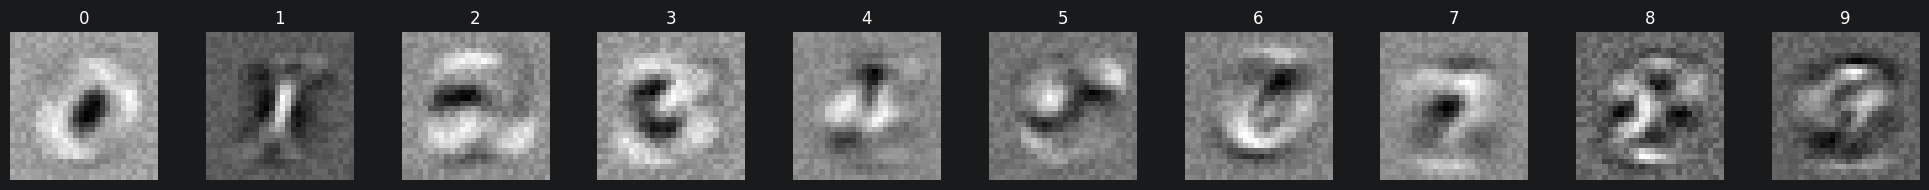

In [26]:
W = model.lin.weight.data
fig, ax = plt.subplots(1, 10, figsize=(20,2))
for i in range(10):
    ax[i].imshow(W[i].detach().view(28,28), cmap="gray")
    ax[i].set_title(str(i))
    ax[i].axis('off')
    plt.tight_layout()